#MAPEO DE SERIES DE TIEMPO DE ANOMALÍAS DE ENOS Y CAUDAL

##DEFINICIONES

In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
# Después de crear el grafo:
def contar_nodos_activos(G):
    """
    Cuenta cuántos nodos de los 24 tienen al menos una conexión.
    """
    nodos_activos = 0
    for nodo in G.nodes():
        if G.degree(nodo, weight='weight') > 0:
            nodos_activos += 1
    return nodos_activos

#MAPEO NIÑO 3.4

len() de nodos es 563
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 11.416666666666666
La distancia minima promedio de la red es: 1.5289855072463767
la distancia maxima es: 2
[[31. 12.  7.  2.  0.  3. 10.  1.  2.  4.  1.  9.  6.  2.  3.  2.  0.  8.
   3.  0.  7.  8. 16. 52.]
 [12.  2.  2.  3.  0.  1.  6.  1.  1.  2.  0.  2.  3.  0.  1.  1.  0.  7.
   1.  0.  0.  0.  4. 15.]
 [ 7.  2.  0.  1.  0.  0.  1.  0.  1.  0.  0.  3.  1.  0.  0.  0.  0.  0.
   0.  0.  1.  0.  2.  5.]
 [ 2.  3.  1.  0.  0.  0.  1.  0.  0.  0.  0.  1.  4.  1.  1.  0.  0.  5.
   0.  0.  0. 

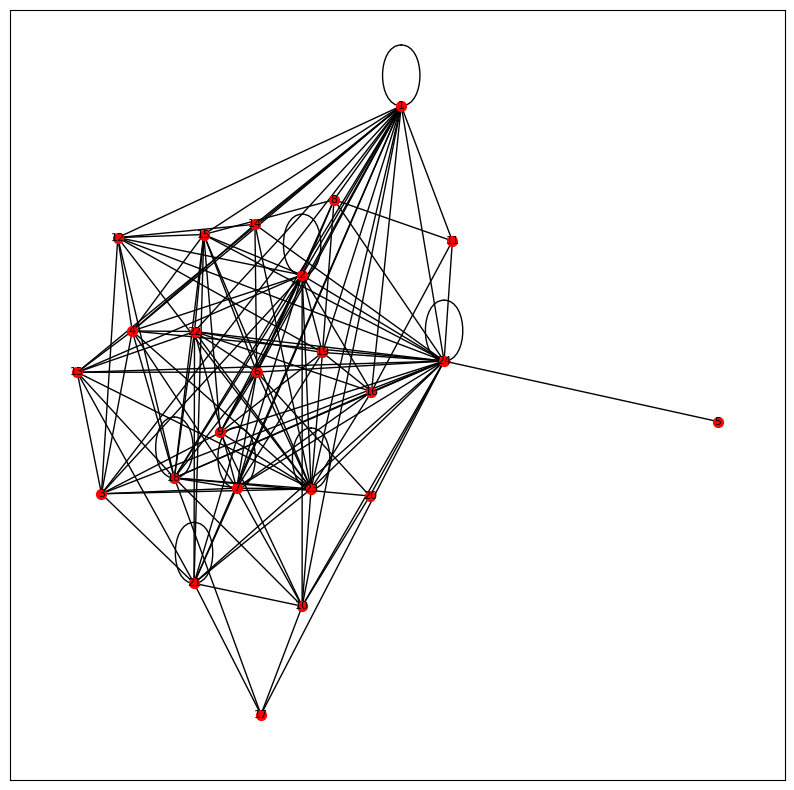

In [4]:

w_opt=4
x =[
0.45, 0.85, 1.09, 1.23, 1.54, 1.90, 2.09, 1.80, 1.20, 0.27, -0.58, -0.97, -1.18,
-1.54, -1.63, -1.66, -1.98, -2.37, -2.26, -2.09, -1.66, -1.45, -1.36, -1.29, -1.20,
-0.90, -0.52, -0.64, -0.94, -1.09, -0.97, -0.45, -0.68, -1.09, -0.96, -1.13, -1.50,
-1.39, -1.52, -1.66, -1.83, -1.66, -1.93, -2.01, -1.26, -0.82, -0.93, -0.74, -0.38,
-0.16, 0.12, 0.30, 0.75, 0.71, 0.49, 0.78, 0.37, 0.19, -0.38, -0.21, 0.01, 0.09,
-0.01, 0.40, 0.63, 0.48, 0.70, 0.62, 0.25, -0.20, -0.70, -0.74, -0.71, -0.55, -0.79,
-0.71, -0.46, -0.38, -0.06, -0.13, -0.22, -0.02, 0.02, -0.25, -0.29, -0.47, -0.10,
0.28, 0.11, 0.29, 0.52, 0.54, 0.22, 0.03, -0.07, 0.08, 0.21, -0.06, -0.38, -0.28,
-0.26, -0.10, 0.05, -0.36, -0.64, -0.64, -0.53, -0.57, -0.46, -0.64, -0.53, -0.19,
-0.30, -0.41, -0.20, 0.13, -0.17, 0.13, 0.21, 0.45, 0.53, 0.37, 0.73, 1.49, 1.99,
1.92, 2.20, 2.35, 1.94, 1.38, 0.95, 0.90, 0.54, -0.11, -0.27, -0.52, -1.16, -1.29,
-1.03, -0.67, -0.19, -0.52, -0.68, -0.73, -0.90, -0.50, -0.24, -0.34, -0.67, -1.19,
-1.34, -1.16, -0.72, -0.79, -1.18, -1.03, -0.91, -0.74, -0.56, -0.70, -0.49, -0.37,
-0.41, -0.66, -0.71, -0.42, -0.33, -0.53, -0.31, -0.11, 0.32, 0.53, 0.81, 1.01, 1.12,
1.14, 1.13, 0.98, 0.58, 0.62, 0.92, 1.29, 1.57, 1.65, 1.24, 1.07, 0.94, 0.90, 0.28,
0.10, -0.44, -1.25, -1.74, -1.74, -1.19, -1.00, -1.90, -2.05, -1.96, -1.97, -1.47,
-1.21, -1.08, -0.88, -0.59, -0.57, -0.53, -0.30, -0.40, -0.45, -0.13, 0.01, 0.21,
0.04, 0.08, 0.08, -0.08, 0.09, 0.22, 0.22, 0.21, 0.10, 0.35, 0.49, 0.32, 0.03, 0.19,
0.26, 0.52, 0.76, 0.68, 0.42, 0.86, 1.20, 1.69, 1.84, 1.78, 1.38, 1.20, 1.04, 0.58,
0.22, 0.05, -0.06, -0.30, -0.28, -0.15, 0.14, 0.41, 0.39, 0.59, 0.78, 0.35, 0.23,
0.13, 0.35, 0.06, 0.00, 0.16, 0.10, 0.06, 0.11, 0.26, 0.31, 0.32, 0.24, 0.53, 0.48,
0.75, 1.11, 1.25, 1.02, 0.73, 0.46, 0.28, -0.11, -0.14, -0.21, -0.63, -0.84, -0.88,
-1.10, -0.95, -0.86, -0.86, -0.61, -0.47, -0.38, -0.44, -0.44, -0.22, -0.45, -0.44,
-0.41, -0.64, -0.53, -0.37, -0.25, 0.16, 0.64, 1.09, 1.56, 1.89, 2.13, 2.36, 2.41,
2.29, 2.38, 2.03, 1.34, 0.78, 0.57, -0.39, -0.99, -1.28, -1.26, -1.46, -1.46, -1.69,
-1.69, -1.32, -0.95, -1.11, -1.15, -1.19, -1.17, -1.22, -1.09, -1.23, -1.58, -1.74,
-1.77, -1.55, -0.98, -0.87, -0.86, -0.79, -0.67, -0.49, -0.52, -0.70, -0.79, -0.92,
-0.73, -0.63, -0.48, -0.49, -0.34, -0.19, -0.04, -0.05, -0.20, -0.14, -0.37, -0.41,
-0.15, -0.04, 0.01, 0.02, 0.31, 0.72, 0.74, 0.87, 1.09, 1.25, 1.47, 1.37, 0.60, 0.64,
0.36, -0.14, -0.61, -0.29, 0.21, 0.26, 0.27, 0.42, 0.33, 0.43, 0.27, 0.23, 0.12,
0.07, 0.06, 0.13, 0.49, 0.76, 0.81, 0.73, 0.66, 0.74, 0.66, 0.36, 0.45, 0.26, 0.30,
0.04, -0.23, -0.05, -0.04, -0.06, -0.59, -0.92, -0.91, -0.67, -0.71, -0.32, -0.09,
0.00, 0.01, 0.31, 0.60, 0.70, 0.99, 1.14, 0.70, 0.13, -0.18, -0.32, -0.47, -0.35,
-0.59, -0.72, -1.11, -1.39, -1.54, -1.58, -1.68, -1.67, -1.21, -0.99, -0.84, -0.68,
-0.30, -0.13, -0.25, -0.35, -0.46, -0.86, -0.89, -0.79, -0.69, -0.35, 0.06, 0.31,
0.48, 0.56, 0.68, 0.89, 1.46, 1.74, 1.52, 1.25, 0.90, 0.38, -0.22, -0.69, -1.07,
-1.39, -1.60, -1.69, -1.64, -1.60, -1.54, -1.11, -0.93, -0.77, -0.52, -0.38, -0.43,
-0.65, -0.80, -1.05, -1.19, -1.06, -0.87, -0.67, -0.61, -0.50, -0.32, 0.02, 0.25,
0.47, 0.38, 0.26, 0.16, -0.25, -0.53, -0.52, -0.25, -0.25, -0.40, -0.42, -0.39,
-0.38, -0.18, -0.20, -0.14, -0.17, -0.49, -0.62, -0.28, 0.08, 0.32, 0.23, -0.06,
-0.03, 0.29, 0.44, 0.75, 0.71, 0.51, 0.42, 0.47, 0.70, 0.92, 1.18, 1.46, 1.93, 2.21,
2.36, 2.72, 2.66, 2.57, 2.26, 1.62, 0.91, 0.30, -0.03, -0.48, -0.58, -0.58, -0.74,
-0.76, -0.50, -0.43, -0.08, 0.03, 0.22, 0.37, 0.34, 0.25, -0.16, -0.43, -0.56, -0.97,
-0.98, -0.98, -0.78, -0.80, -0.51, -0.20, 0.04, 0.12, 0.09, 0.47, 0.90, 0.90, 0.89,
0.65, 0.71, 0.81, 0.62, 0.55, 0.45, 0.35
]

nodos = crear_ind(x , w_opt)
print("len() de nodos es",len(nodos))

G, unique_nodes, nodo_a_sublista= crear_grafo(nodos, w_opt)
A = nx.to_numpy_array(G)
print(unique_nodes)
print("len() de unique_nodes es",len(unique_nodes))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)  # Layout para la visualización
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G, pos, edge_color="black")
# Etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G):
    grados = [grado for _, grado in G.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G)
distancia_media=nx.average_shortest_path_length(G)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G))
print(A)
plt.show()

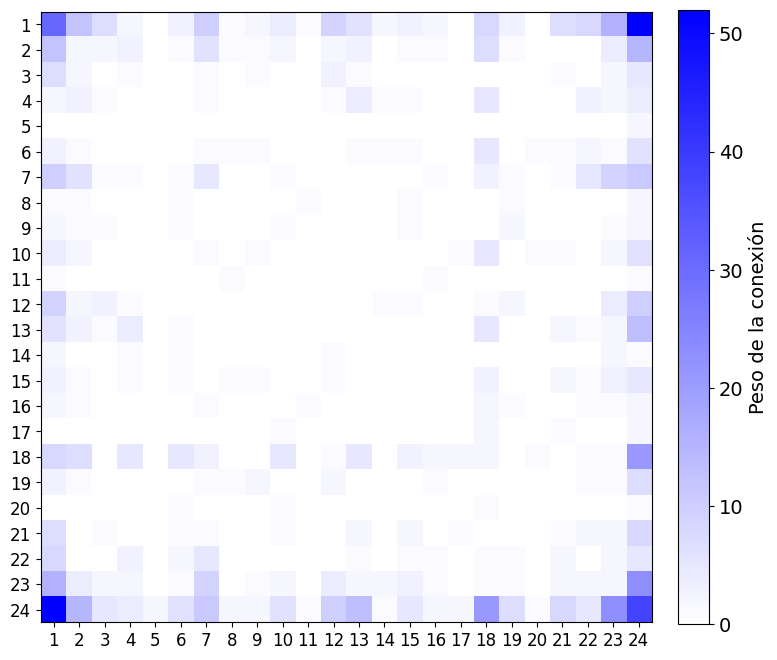

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
azul_personalizado = LinearSegmentedColormap.from_list(
    'azul_personalizado',
    [(1, 1, 1), (0, 0, 1)]  # Blanco → Azul
)

im = ax.imshow(C, cmap=azul_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.show()

In [6]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
#A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
#plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')

NIÑO 3.4
[[31 12  7  2  0  3 10  1  2  4  1  9  6  2  3  2  0  8  3  0  7  8 16 52]
 [12  2  2  3  0  1  6  1  1  2  0  2  3  0  1  1  0  7  1  0  0  0  4 15]
 [ 7  2  0  1  0  0  1  0  1  0  0  3  1  0  0  0  0  0  0  0  1  0  2  5]
 [ 2  3  1  0  0  0  1  0  0  0  0  1  4  1  1  0  0  5  0  0  0  3  2  4]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2]
 [ 3  1  0  0  0  0  1  1  1  0  0  0  1  1  1  0  0  5  0  1  1  2  1  6]
 [10  6  1  1  0  1  5  0  0  1  0  0  0  0  0  1  0  3  1  0  1  5  9 11]
 [ 1  1  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  1  0  0  0  0  2]
 [ 2  1  1  0  0  1  0  0  0  1  0  0  0  0  1  0  0  0  2  0  0  0  1  2]
 [ 4  2  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  5  0  1  1  0  2  6]
 [ 1  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1]
 [ 9  2  3  1  0  0  0  0  0  0  0  0  0  1  1  0  0  1  2  0  0  0  4 10]
 [ 6  3  1  4  0  1  0  0  0  0  0  0  0  0  0  0  0  5  0  0  2  1  2 13]
 [ 2  0  0  1  0

In [7]:
nodos_activos = contar_nodos_activos(G)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#Mapeo anomalias caudal Manaos

len() de nodos es 563
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24


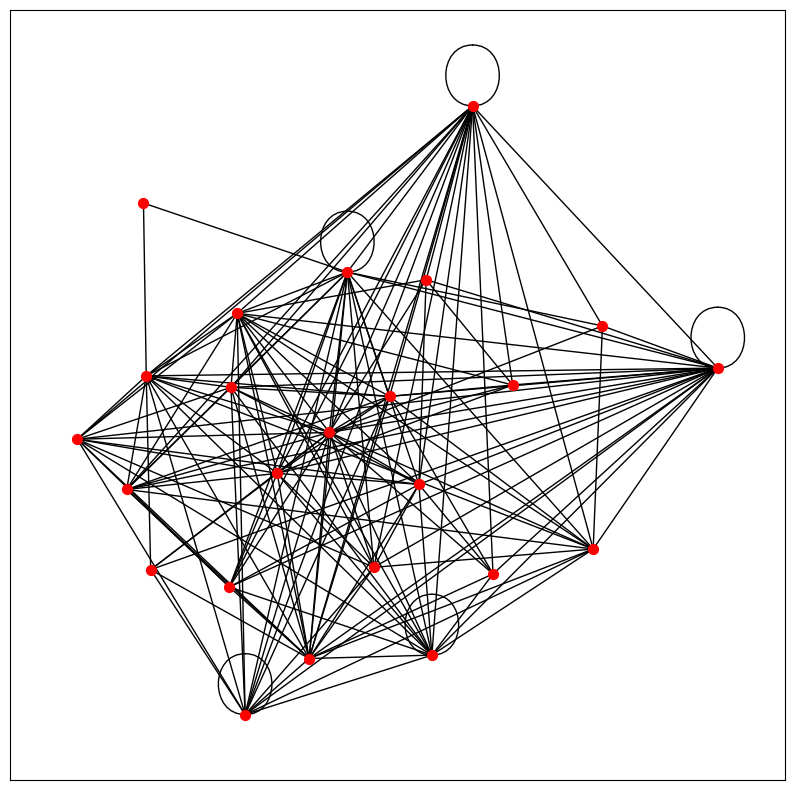

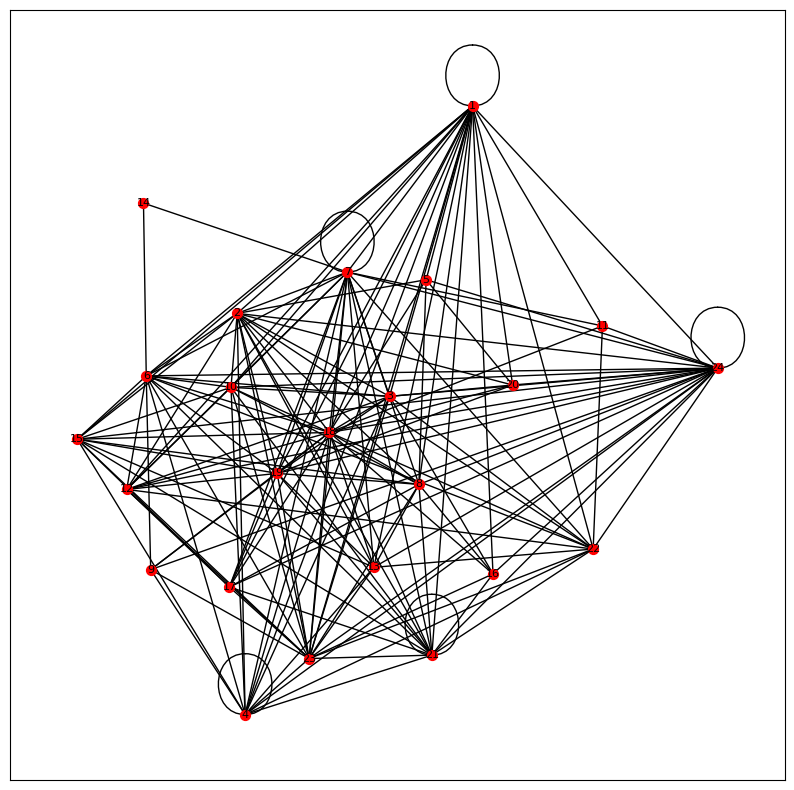

El grado medio de la red es: 13.5
La distancia minima promedio de la red es: 1.4420289855072463
la distancia maxima es: 3
[[ 3.  8.  4.  6.  1.  6.  9.  6.  0.  4.  3.  9.  5.  0.  4.  3.  5. 10.
   3.  5.  8.  6. 10. 48.]
 [ 8.  0.  2.  2.  1.  2.  3.  2.  0.  1.  0.  2.  1.  0.  1.  0.  0.  5.
   5.  2.  2.  2.  4. 21.]
 [ 4.  2.  0.  2.  0.  1.  2.  0.  0.  1.  0.  2.  0.  0.  0.  1.  0.  2.
   1.  1.  0.  3.  2. 10.]
 [ 6.  2.  2.  1.  0.  2.  3.  0.  1.  2.  0.  0.  1.  0.  2.  0.  0.  2.
   0.  0.  1.  4.  6. 10.]
 [ 1.  1.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.
   0.  1.  0.  0.  0.  5.]
 [ 6.  2.  1.  2.  0.  0.  2.  0.  1.  1.  0.  1.  0.  1.  1.  0.  0.  1.
   1.  0.  3.  2.  2.  7.]
 [ 9.  3.  2.  3.  0.  2.  1.  2.  0.  1.  1.  2.  4.  1.  0.  0.  2.  8.
   1.  0.  2.  2.  9. 16.]
 [ 6.  2.  0.  0.  1.  0.  2.  0.  0.  1.  0.  0.  1.  0.  2.  1.  1.  3.
   1.  0.  1.  0.  4.  4.]
 [ 0.  0.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. 

In [8]:

w_opt=4
x1 =[
    0.2246310914, 0.3973431667, 0.666494041, 1.263104567, 1.764575077,
    0.6841388598, 0.434871419, 0.5257798419, 0.05160200331, -0.1965436434,
    -0.4985893152, -0.1526719115, 0.2656389689, 0.4648025929, 0.8933586899,
    1.422933355, 2.045740125, 0.8519052682, 0.9154673902, 0.363044028,
    0.2248532475, 0.07496660229, -0.1221198585, 0.1668337701, 0.2238109338,
    0.3625844115, 0.7243420113, 1.12259716, 1.661599253, 1.909946378,
    1.000222622, 0.4428198306, 0.7802696625, 0.6284208777, 0.442982286,
    0.4373720272, 0.563902932, 0.8700165024, 1.286389538, 1.47196257,
    1.587423281, 0.4429889135, -0.2320496469, -0.5932705373, 0.1025041423,
    -0.07829409149, 0.1068393672, 0.03995132754, 0.2150625866, 0.3447476818,
    0.5871836353, 0.7453141287, 0.5043277941, -0.124763427, -0.4102491527,
    -0.5376037443, -1.59749844, -0.8587643204, -0.3436505113, 0.09784651455,
    0.113636436, 0.1247613495, 0.2055547064, 0.305728513, 1.035715527,
    2.0698951, 1.883984225, 1.09728846, -0.1089653842, -0.1084361341,
    -0.9435077642, -0.5506336876, -0.1359648456, -0.02456409235, 0.3064952228,
    0.1753495096, 1.006351855, 1.268040144, 0.4193616268, 0.5351618857,
    -0.9713823214, -1.415696524, -0.8864669374, -0.5928376557, -0.481251175,
    -0.6216371836, -0.9471289806, -0.7374002825, -0.643674487, -0.8967456913,
    -0.8635621241, -1.007103959, -1.561891655, -3.143484781, -2.505763153,
    -2.361075704, -2.422290715, -2.545808696, -1.851955074, -1.241949607,
    -0.2721405975, 0.4014467552, 0.008040750606, -1.03257763, -1.199179837,
    -0.5201532505, -0.5688954506, -0.9929637379, -1.139564303, -0.8400227838,
    -0.3281892331, -1.064976722, -1.099871374, -1.139579008, -1.313494376,
    -0.04385236759, -0.07259172347, -0.3006496215, -0.6275281144,
    -0.2849651192, -0.09987791336, 0.3115896588, 0.3526059237, 0.4070125483,
    0.08811692051, -0.1169172089, 0.6294407246, 0.7910642374, 0.3866719573,
    -0.5090934395, -1.226854755, -1.363330612, -1.334761801, -1.823078131,
    -2.582348578, -1.595298641, -0.8875598507, -0.3050837844, -0.3945910833,
    -0.122576244, -0.3094005242, 0.191824983, -0.09505862901, -0.3680203641,
    -0.4041563651, -0.3584310832, -0.126324968, -0.006268248624, 0.07532951518,
    0.04320270335, -0.3554162543, 0.3875510636, -0.7088037367, -1.493300691,
    -2.331138631, -2.565602626, -2.301454169, -1.730944562, -0.8946298516,
    -0.1396470658, 0.6438841683, 0.6140364677, 0.279654875, -1.010572472,
    -1.039522502, -0.6828043499, -0.7126913953, -0.573088363, -0.398962034,
    -0.236546764, 0.1839245958, 0.4446715009, 1.143359769, 1.769285087,
    1.584138127, 0.7018495302, 0.7907921445, 0.6003655918, 0.5886353739,
    0.3061609725, -0.009660582646, -0.6781201608, -0.6899151067,
    -0.2863960208, -0.2882658088, -0.2781498576, -0.1056878406, -0.02668038443,
    0.2275775211, 0.2242856443, -0.5996709664, -0.6856322779, -0.5788499237,
    -0.5013535965, -0.7433532173, -0.7114018963, -0.5225211512, -0.3855431844,
    0.01622565052, -0.7174546804, -0.02720285515, 0.4570749583, 0.532921078,
    0.3884046026, 0.3386329911, 0.8487496325, 1.174717804, 0.9866701141,
    0.6375919529, 1.097135248, -1.279704127, -2.833787883, -0.298114108,
    0.3091470875, -0.0008749382667, -0.3431308445, -0.8834017613, -1.048346639,
    -0.4612227974, -0.08115069702, -1.181219118, -1.044111933, -0.2931694974,
    0.7970914898, -0.08462147992, -0.6119937359, -0.5391811594, -0.3991322637,
    -0.3574073847, -0.1471344397, -0.1971007021, -0.09252095895,
    -0.06122734417, -0.920626726, -0.5834665455, -2.246159208, -2.813147154,
    -1.781667294, -0.9177730656, -1.339252707, -1.971750833, -2.436593028,
    -2.152328564, -1.140697828, -0.3702450299, -0.3176947968, 0.2859714825,
    0.8325726735, 0.8394230748, 0.7299763752, 0.6265741564, 0.6183621211,
    0.7976478343, 0.6349375527, 0.2756429719, 0.361225068, 0.5992748424,
    1.278967786, 2.088992243, 1.808418948, 1.453708511, 1.083101998,
    0.9762476899, 0.7587714765, 0.7544528699, 1.038093378, 1.285551161,
    1.231364602, 1.396604521, 1.713305887, 1.757859662, 0.5574229169,
    -0.6245670024, -1.446603711, -1.135032289, -0.9017923453, -0.8495019158,
    -0.8237867863, -1.040406737, -1.800753629, -1.674131871, -1.053812711,
    -0.005126262302, -0.0589204985, -0.006780610258, 0.2701942939,
    0.1752883593, 0.02236634083, 0.01658445902, -0.1123756845, -0.4249378676,
    -0.3703585507, -0.1912890135, 0.7547548225, -0.234511048, -0.3468639512,
    -1.210384859, -0.167305862, 0.7112068249, 0.7357757247, 0.3793674828,
    0.4792091823, -0.1895385472, -0.7862843447, -1.312656505, -1.679056432,
    -1.038914708, -0.4203850579, -0.3089778597, -0.5193649202, -0.6829771041,
    -0.5885090436, -0.2343837519, -0.3172693994, -0.5087587382, -0.9501290127,
    -1.412632815, -0.6447822299, -0.5103955549, -1.648039702, -0.02586621555,
    0.9384201932, 0.9568803394, 0.5580320898, 0.8099501976, 1.301070802,
    1.311037803, 0.4806208823, -0.02358681597, -1.012784124, -1.831604472,
    -0.675860953, -1.133045106, -1.098973214, -1.101364936, -0.7970940398,
    -0.3699831338, 0.2185185181, 0.789064668, 1.029860981, 1.273556755,
    0.1331631601, -1.78952341, -0.7942452873, 0.4258042147, 0.5437912964,
    0.4994925004, 0.1240887255, -0.04629428663, 0.07765408911, 0.1237291716,
    -0.2683003699, -0.4622827744, -0.6928010845, -0.7264353951, 0.4959847453,
    0.06451337312, 0.492317962, 0.5626353691, 0.420328117, 0.4701315852,
    0.4254703173, 0.644025554, 1.030522231, 0.2123374294, 0.4716918058,
    1.210390686, 0.9128317935, 0.08643995049, -0.1000891069, -0.05075249843,
    0.006945660179, 0.2667325124, 0.7270939892, 0.9320916787, 0.6115643668,
    0.1317279116, 0, 0, 0, 0, -0.3736484653, -1.216990904, -0.5484668754,
    -0.8433560818, -1.274343528, -0.7860552428, -0.189152894, 0.08411323766,
    0.7850192345, 0.7734145557, 1.024688355, 0.4394081783, -0.1300672265,
    0.4482642074, 0.1068393672, -0.03958692003, -0.3289752562, -0.8564874573,
    -1.473864094, -1.370248095, -1.652571449, -0.5685740535, -0.7560611741,
    -0.7071628627, 0.2185113192, 0.614045442, 0.3939006443, 0.2266227249,
    -0.197476662, -0.9118270544, -1.419000743, -1.170712094, -0.9184571087,
    -0.8975160473, -0.00239796233, 0.9336713028, 1.019727226, 0.06059116657,
    -0.4094464418, -0.1478022229, -0.2420385557, -0.4005074711, -0.4155815872,
    -0.9095025023, -0.8005288151, -0.05332004492, 0.5739257513, 0.4622662486,
    1.16910136, 0.7109637022, 0.4880843351, 0.1113734274, -0.2531106826,
    -0.7411890075, -0.2573967315, 0.1693660101, -0.2536699009, -0.01177788664,
    0.4848111707, 0.0611980923, 1.051294672, 1.325397648, 1.345023268,
    1.52818228, 1.528681599, 1.442163907, 1.491624076, 1.086051042,
    0.09127430454, -0.7861568139, -0.7011986203, 0.2147793059, -0.2112040945,
    -0.1383463149, -0.3505484718, -0.4280798572, -0.3790959955, -0.604715158,
    -1.189855711, -2.038271143, -2.281205422, -2.308665502, -1.809857913,
    -2.254944212, -1.362477382, -1.118913335, -1.080671055, -0.8161669869,
    -0.8538760894, -0.1695446898, 0.239257437, -1.025882375, -0.8574068332,
    -1.460817442, -0.7059434898, 1.000141661, 1.537850448, 1.616286196,
    1.600524646, 1.936923965, 1.708296103, 1.04083749, 0.1035075333,
    -0.5989088794, -0.7162266615, -1.19441694, -1.566455232, -0.1072806696,
    1.005223264, 1.151037525, 1.690451902, 1.631798432, 1.420147416,
    1.054558052, 0.9203544094, 0.9654778812, 0.5736323736, 0.7935579374,
    0.9369379247, 0.6514139373, 0.9563079425, 0.9792278818, 1.099349753,
    1.207323907, 1.545631522, 1.470977086, 1.396552194, 1.469527237,
    1.3552931, 1.348471012, 1.335002822, 1.241203326, 1.700560251, 1.846159401,
    2.030574414, 2.342772972, 2.523532709, 2.368073117, 2.162157506,
    2.093536888, 0.00832531549, -0.7044705507, -1.127050659, -0.7233682111,
    -1.319350897, -0.3944377465, 0.08455364883, 0.3183351941, 0.3829214989,
    0.1345944184, 0.04572523574, -0.1285943593, 0, 0, 0, 0, 0, 1.657993065,
    1.645325345, 1.436003796, 0.9120928903, -0.2890095574, -1.074193892,
    -0.3758987693, 0.4599367445, 0.4740165925, 0.5362991032, 1.056698109,
    0.5801936095, -0.2141810998, -0.1632229035, 0.09613974155, 0.3815645212,
    0.2706127136, 0.6312728208, -0.36179151, -0.2811171547, 1.292862449,
    2.119447915, 2.349257047, 2.025852347, 1.816207028, 1.668050559,
    1.466896397, 1.284834805
]

nodos1 = crear_ind(x1 , w_opt)
print("len() de nodos es",len(nodos1))

G1, unique_nodes1, nodo_a_sublista1= crear_grafo(nodos1, w_opt)
A1 = nx.to_numpy_array(G1)
print(unique_nodes1)
print("len() de unique_nodes es",len(unique_nodes1))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)  # Layout para la visualización
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
labels = {i: i+1 for i in G1.nodes()}
nx.draw_networkx_labels(G1, pos, labels, font_size=8)
plt.show()
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G1):
    grados = [grado for _, grado in G1.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G1)
distancia_media=nx.average_shortest_path_length(G1)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G1))
print(A1)
plt.show()

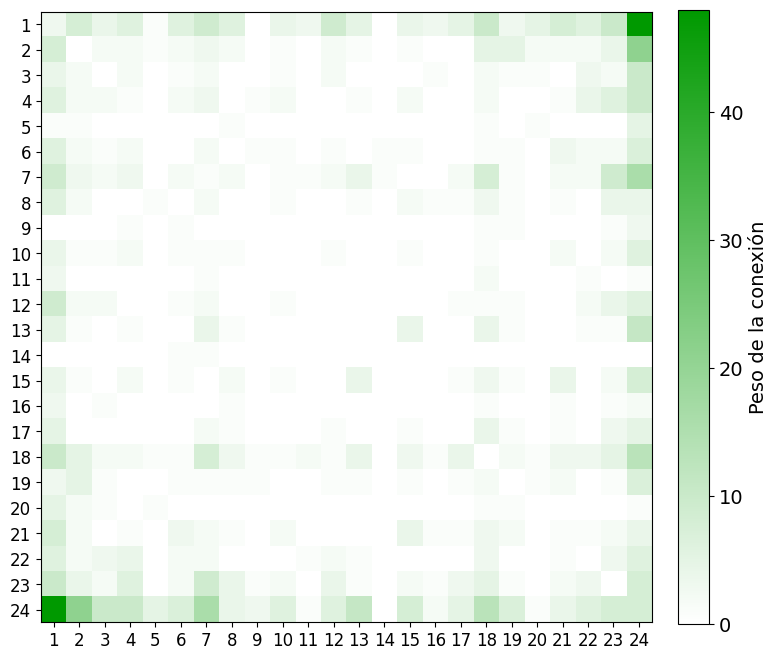

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G1).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Verde
verde_personalizado = LinearSegmentedColormap.from_list(
    'verde_personalizado',
    [(1, 1, 1), (0, 0.6, 0)]  # Blanco → Verde
)


im = ax.imshow(C, cmap=verde_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
print(unique_nodes)
print(nodo_a_sublista)
print(unique_nodes1)
print(nodo_a_sublista1)

{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
{0: (1, 2, 3, 4), 1: (1, 2, 4, 3), 2: (1, 3, 2, 4), 3: (1, 3, 4, 2), 4: (1, 4, 2, 3), 5: (1, 4, 3, 2), 6: (2, 1, 3, 4), 7: (2, 1, 4, 3), 8: (2, 3, 1, 4), 9: (2, 3, 4, 1), 10: (2, 4, 1, 3), 11: (2, 4, 3, 1), 12: (3, 1, 2, 4), 13: (3, 1, 4, 2), 14: (3, 2, 1, 4), 15: (3, 2, 4, 1), 16: (3, 4, 1, 2), 17: (3, 4, 2, 1), 18: (4, 1, 2, 3), 19: (4, 1, 3, 2), 20: (4, 2, 1, 3), 21: (4, 2, 3, 1), 22: (4, 3, 1, 2), 23: (4, 3, 2, 1)}
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, 

In [11]:
nodos_activos = contar_nodos_activos(G1)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


## W OPTIMO

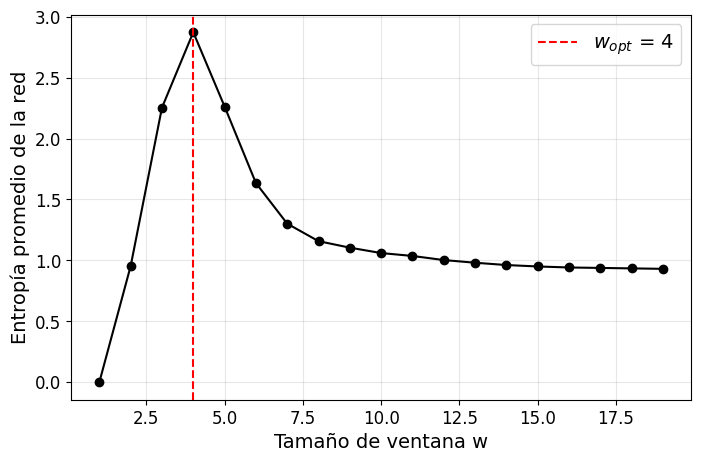

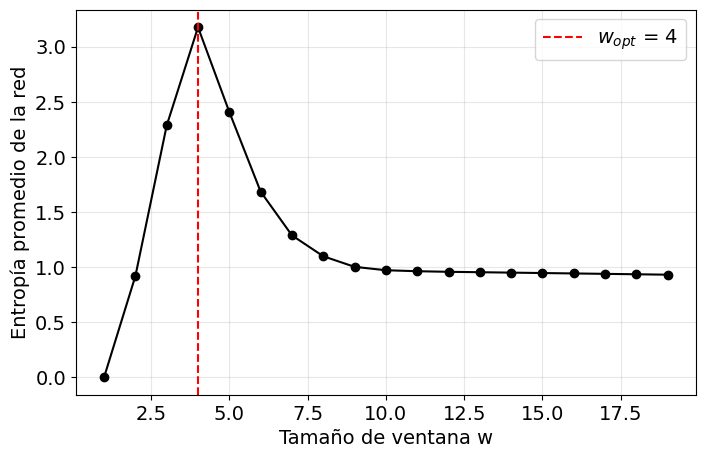

4
4


In [12]:
ventana=optimizar_w(x,1,20)
ventana1=optimizar_w(x1,1,20)
print(ventana)
print(ventana1)

##INTERSECCIÓN

NIÑO 3.4
[[31 12  7  2  0  3 10  1  2  4  1  9  6  2  3  2  0  8  3  0  7  8 16 52]
 [12  2  2  3  0  1  6  1  1  2  0  2  3  0  1  1  0  7  1  0  0  0  4 15]
 [ 7  2  0  1  0  0  1  0  1  0  0  3  1  0  0  0  0  0  0  0  1  0  2  5]
 [ 2  3  1  0  0  0  1  0  0  0  0  1  4  1  1  0  0  5  0  0  0  3  2  4]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2]
 [ 3  1  0  0  0  0  1  1  1  0  0  0  1  1  1  0  0  5  0  1  1  2  1  6]
 [10  6  1  1  0  1  5  0  0  1  0  0  0  0  0  1  0  3  1  0  1  5  9 11]
 [ 1  1  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  1  0  0  0  0  2]
 [ 2  1  1  0  0  1  0  0  0  1  0  0  0  0  1  0  0  0  2  0  0  0  1  2]
 [ 4  2  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  5  0  1  1  0  2  6]
 [ 1  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  1]
 [ 9  2  3  1  0  0  0  0  0  0  0  0  0  1  1  0  0  1  2  0  0  0  4 10]
 [ 6  3  1  4  0  1  0  0  0  0  0  0  0  0  0  0  0  5  0  0  2  1  2 13]
 [ 2  0  0  1  0

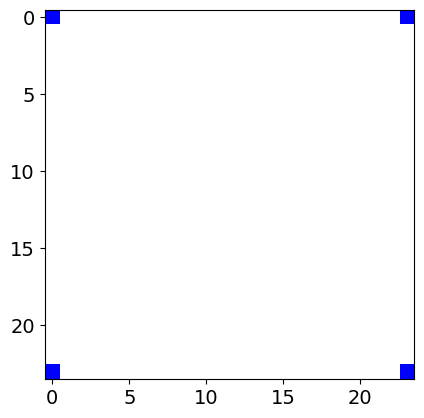

In [13]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')



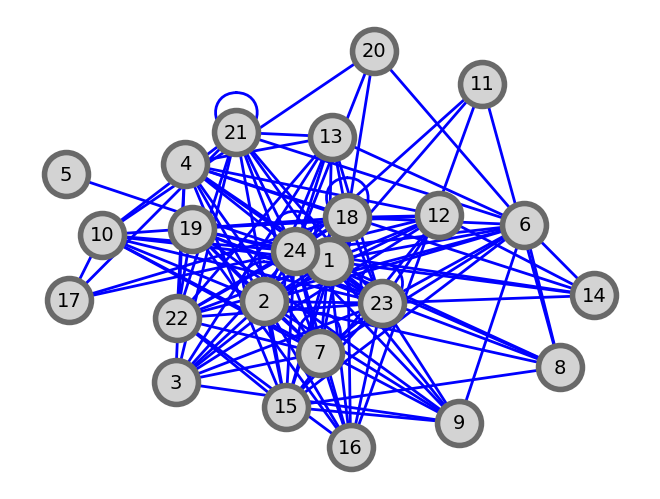

In [14]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}

nx.draw(
    G, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='blue',
    width=2,
    font_size=14
)
plt.show()

CALAMAR
[[ 3  8  4  6  1  6  9  6  0  4  3  9  5  0  4  3  5 10  3  5  8  6 10 48]
 [ 8  0  2  2  1  2  3  2  0  1  0  2  1  0  1  0  0  5  5  2  2  2  4 21]
 [ 4  2  0  2  0  1  2  0  0  1  0  2  0  0  0  1  0  2  1  1  0  3  2 10]
 [ 6  2  2  1  0  2  3  0  1  2  0  0  1  0  2  0  0  2  0  0  1  4  6 10]
 [ 1  1  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  1  0  1  0  0  0  5]
 [ 6  2  1  2  0  0  2  0  1  1  0  1  0  1  1  0  0  1  1  0  3  2  2  7]
 [ 9  3  2  3  0  2  1  2  0  1  1  2  4  1  0  0  2  8  1  0  2  2  9 16]
 [ 6  2  0  0  1  0  2  0  0  1  0  0  1  0  2  1  1  3  1  0  1  0  4  4]
 [ 0  0  0  1  0  1  0  0  0  0  0  0  0  0  0  0  0  1  1  0  0  0  1  3]
 [ 4  1  1  2  0  1  1  1  0  0  0  1  0  0  1  0  0  1  0  0  2  0  2  6]
 [ 3  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  2  0  0  0  1  0  1]
 [ 9  2  2  0  0  1  2  0  0  1  0  0  0  0  0  0  1  1  1  0  0  2  4  6]
 [ 5  1  0  1  0  0  4  1  0  0  0  0  0  0  4  0  0  4  1  0  0  1  1 11]
 [ 0  0  0  0  0 

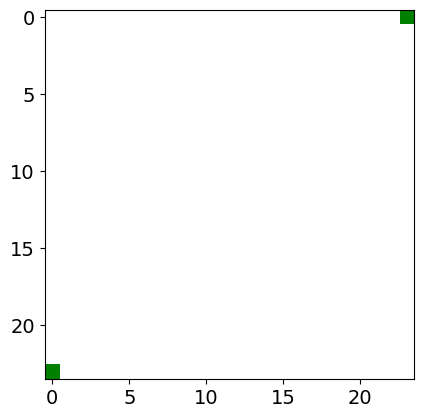

In [15]:
print("CALAMAR")
print(A1)
cmap = ListedColormap(['white', 'green'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')


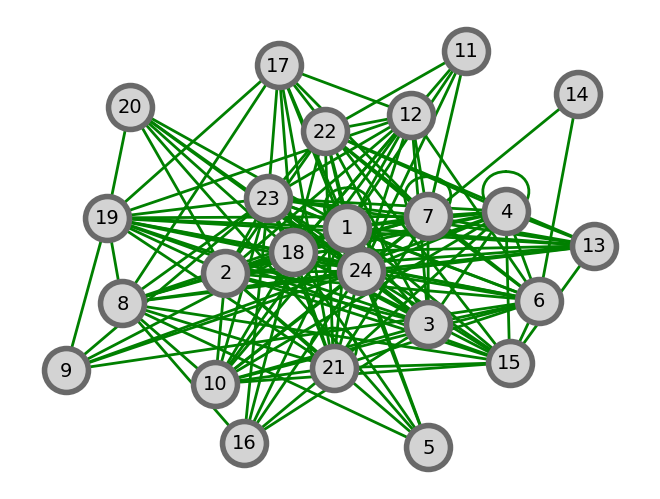

In [16]:
G1 = nx.from_numpy_array(A1)
pos = nx.spring_layout(G1, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G1.nodes()}

nx.draw(
    G1, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='green',
    width=2,
    font_size=14
)
plt.show()

In [17]:
print(A.shape, A1.shape)

(24, 24) (24, 24)


##INTERCEPCIÓN


In [18]:
C = np.divide(A1 ,A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)
#print(C_clean)
C_clean_beauty = np.array(C_clean, dtype=int)
print(C_clean_beauty)

[[  9  66  57 300   0 200  90 600   0 100 300 100  83   0 133 150   0 125
  100   0 114  75  62  92]
 [ 66   0 100  66   0 200  50 200   0  50   0 100  33   0 100   0   0  71
  500   0   0   0 100 140]
 [ 57 100   0 200   0   0 200   0   0   0   0  66   0   0   0   0   0   0
    0   0   0   0 100 200]
 [300  66 200   0   0   0 300   0   0   0   0   0  25   0 200   0   0  40
    0   0   0 133 300 250]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0 250]
 [200 200   0   0   0   0 200   0 100   0   0   0   0 100 100   0   0  20
    0   0 300 100 200 116]
 [ 90  50 200 300   0 200  20   0   0 100   0   0   0   0   0   0   0 266
  100   0 200  40 100 145]
 [600 200   0   0   0   0   0   0   0   0   0   0   0   0 200   0   0   0
  100   0   0   0   0 200]
 [  0   0   0   0   0 100   0   0   0   0   0   0   0   0   0   0   0   0
   50   0   0   0 100 150]
 [100  50   0   0   0   0 100   0   0   0   0   0   0   0   0   0   0  20
    0   0 200   0

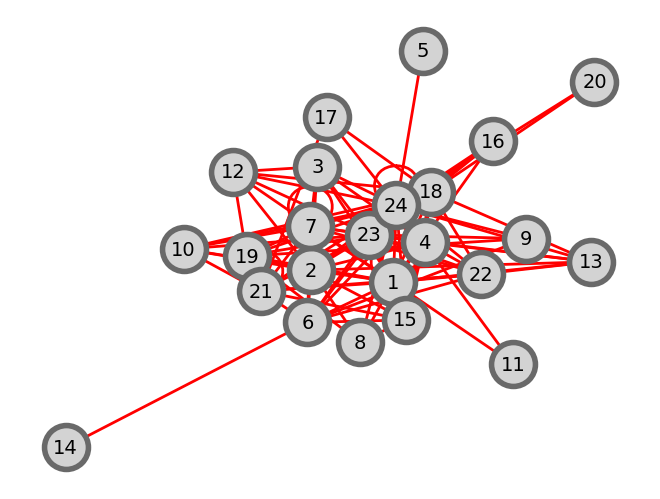

In [19]:
GC = nx.from_numpy_array(C_clean)
pos = nx.spring_layout(GC, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in GC.nodes()}

nx.draw(
    GC, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='red',
    width=2,
    font_size=14
)
plt.show()

INTERCEPCIÓN


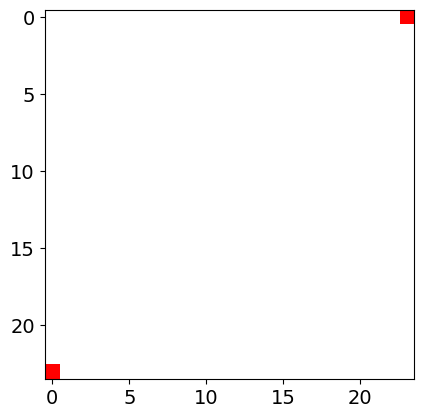

In [20]:
print("INTERCEPCIÓN")
#print(C_clean)
cmap = ListedColormap(['white', 'red'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')

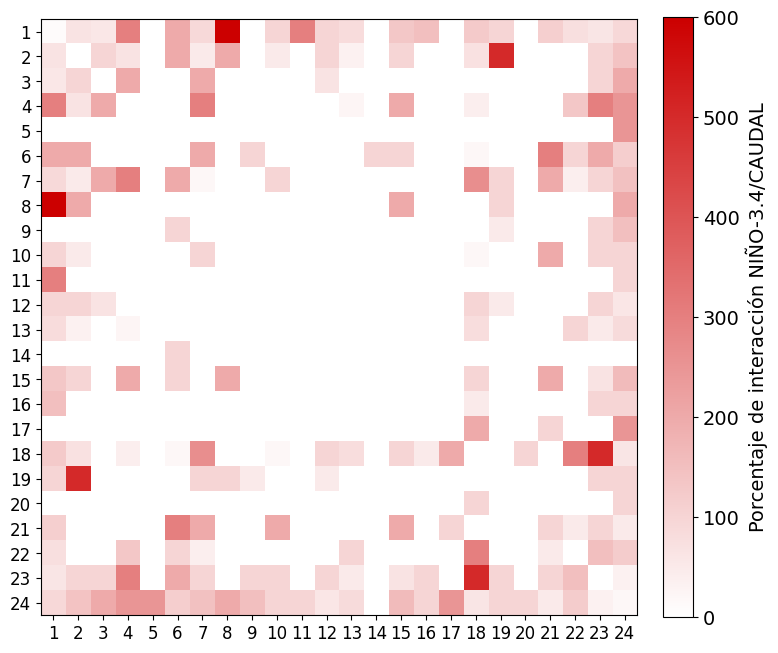

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(GC).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Rojo
rojo_personalizado = LinearSegmentedColormap.from_list(
    'rojo_personalizado',
    [(1, 1, 1), (0.8, 0, 0)]  # Blanco → Rojo
)

im = ax.imshow(C, cmap=rojo_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Porcentaje de interacción NIÑO-3.4/CAUDAL', fontsize=14)

plt.tight_layout()
plt.show()



In [22]:
nodos_activos = contar_nodos_activos(GC)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#PORCENTAJE DE INTERACCIÓN

In [23]:
upper = np.triu(C_clean)
promedio = np.mean(upper)
print("La influencia del NIÑO 3.4 en el caudal es:",promedio,"%")

La influencia del NIÑO 3.4 en el caudal es: 24.485217916844267 %


##MÉTRICAS

In [24]:
import networkx as nx
import numpy as np

# Intento de importar correctamente python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red(G, nombre_grafo):
    """
    Calcula e imprime métricas de red considerando solo nodos activos.
    Las etiquetas en pantalla se muestran como 1‑based.
    """
    print(f"\n=== Métricas para {nombre_grafo} ===")

    # Identificar nodos activos (grado > 0)
    nodos_activos = [n for n in G.nodes() if G.degree(n) > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos activos: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos activos. No se pueden calcular métricas.")
        return

    # Subgrafo inducido por los nodos activos
    G_activo = G.subgraph(nodos_activos).copy()

    # ---- Grado medio (solo activos) ----
    grados = [d for n, d in G_activo.degree()]
    grado_medio = np.mean(grados)
    print(f"Grado medio (solo activos): {grado_medio:.4f}")

    # ---- Coeficiente de clustering promedio (solo activos) ----
    clustering = nx.average_clustering(G, nodes=nodos_activos)
    print(f"Coeficiente de clustering promedio (solo activos): {clustering:.4f}")

    # ---- Diámetro y distancia promedio ----
    if nx.is_connected(G_activo):
        diametro = nx.diameter(G_activo)
        dist_prom = nx.average_shortest_path_length(G_activo)
        print(f"Diámetro (componente activa): {diametro}")
        print(f"Distancia promedio (componente activa): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante)
        dist_prom = nx.average_shortest_path_length(G_gigante)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro: {diametro}")
        print(f"  Distancia promedio: {dist_prom:.4f}")

    # ---- Modularidad (sobre grafo activo) ----
    # (Requiere python-louvain instalado)
    particion = community_louvain.best_partition(G_activo)
    modularidad = community_louvain.modularity(particion, G_activo)
    print(f"Modularidad (sobre grafo activo): {modularidad:.4f}")

    # ---- Centralidades ----
    # Centralidad de grado (solo activos)
    cent_grado = nx.degree_centrality(G_activo)
    prom_cent_grado = np.mean(list(cent_grado.values()))
    print(f"Centralidad de grado promedio (activos): {prom_cent_grado:.4f}")

    # Top 3 nodos con mayor centralidad de grado (etiquetas 1‑based)
    top_nodos = sorted(cent_grado.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos activos con mayor centralidad de grado:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.4f}")

    # Centralidad de cercanía (sobre la componente usada)
    if nx.is_connected(G_activo):
        cent_cercania = nx.closeness_centrality(G_activo)
    else:
        cent_cercania = nx.closeness_centrality(G_gigante)
    prom_cent_cercania = np.mean(list(cent_cercania.values()))
    print(f"Centralidad de cercanía promedio (componente usada): {prom_cent_cercania:.4f}")

    # Centralidad de intermediación (betweenness) sobre todo el grafo activo
    cent_inter = nx.betweenness_centrality(G_activo)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio (activos): {prom_cent_inter:.4f}")

In [25]:
calcular_metricas_red(G, "NIÑO 3.4")
calcular_metricas_red(G1, "MANAOS")
calcular_metricas_red(GC, "INTERSECCIÓN")


=== Métricas para NIÑO 3.4 ===
Nodos activos: 24 de 24
Grado medio (solo activos): 11.4167
Coeficiente de clustering promedio (solo activos): 0.6728
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.5290
Modularidad (sobre grafo activo): 0.1004
Centralidad de grado promedio (activos): 0.4964
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0870
  Nodo 1: 0.9565
  Nodo 23: 0.8696
Centralidad de cercanía promedio (componente usada): 0.6697
Centralidad de intermediación promedio (activos): 0.0240

=== Métricas para MANAOS ===
Nodos activos: 24 de 24
Grado medio (solo activos): 13.5000
Coeficiente de clustering promedio (solo activos): 0.8012
Diámetro (componente activa): 3
Distancia promedio (componente activa): 1.4420
Modularidad (sobre grafo activo): 0.0585
Centralidad de grado promedio (activos): 0.5870
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0435
  Nodo 1: 1.0000
  Nodo 18: 0.9565
Centralidad de cercanía promedio (compo

##MÉTRICAS PESADAS

In [26]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red_pesada(G, nombre_grafo, usar_inverso_para_distancias=True):
    """
    Calcula e imprime métricas de red considerando pesos en las aristas.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight'
    - nombre_grafo: título para la salida
    - usar_inverso_para_distancias: si True, usa 1/weight como distancia para caminos;
      si False, ignora los pesos para distancias (trata como no pesado).
    """
    print(f"\n=== Métricas PESADAS para {nombre_grafo} ===")

    # Nodos activos (grado no pesado > 0, pero usaremos fuerza > 0 para activos pesados)
    # Consideramos nodos activos aquellos con fuerza > 0
    fuerzas = dict(G.degree(weight='weight'))
    nodos_activos = [n for n, f in fuerzas.items() if f > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos con fuerza > 0: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos con fuerza positiva. No se pueden calcular métricas.")
        return

    # ---- Grado medio pesado (fuerza promedio) ----
    fuerza_promedio = np.mean(list(fuerzas.values()))
    print(f"Fuerza promedio (grado pesado): {fuerza_promedio:.4f}")

    # ---- Coeficiente de clustering pesado ----
    # Utiliza la definición estándar de clustering pesado de NetworkX
    clustering_pesado = nx.average_clustering(G, weight='weight')
    print(f"Coeficiente de clustering pesado promedio: {clustering_pesado:.4f}")

    # ---- Preparar grafo con distancias (inverso del peso) si se requiere ----
    if usar_inverso_para_distancias:
        # Crear una copia del grafo con atributo 'distance' = 1/weight
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
    else:
        G_dist = G  # usa el grafo original sin considerar pesos para distancias

    # ---- Diámetro y distancia promedio pesados ----
    # Se calculan sobre el subgrafo de nodos activos (para evitar aislados)
    G_activo = G.subgraph(nodos_activos).copy()
    if usar_inverso_para_distancias:
        G_dist_activo = G_dist.subgraph(nodos_activos).copy()
    else:
        G_dist_activo = G_activo

    if nx.is_connected(G_dist_activo):
        diametro = nx.diameter(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        print(f"Diámetro (pesado): {diametro}")
        print(f"Distancia promedio (pesada): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_dist_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_dist_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro (pesado): {diametro}")
        print(f"  Distancia promedio (pesada): {dist_prom:.4f}")

    # ---- Modularidad pesada ----
    # La partición de Louvain puede usar pesos
    particion = community_louvain.best_partition(G, weight='weight')
    modularidad = community_louvain.modularity(particion, G, weight='weight')
    print(f"Modularidad (pesada): {modularidad:.4f}")

    # ---- Centralidades pesadas ----
    # Centralidad de grado pesada (fuerza normalizada)
    # Normalizamos por la suma total de fuerzas de la red (o por el máximo posible)
    total_fuerza = sum(fuerzas.values())
    cent_fuerza = {n: f / total_fuerza for n, f in fuerzas.items()}
    prom_cent_fuerza = np.mean(list(cent_fuerza.values()))
    print(f"Centralidad de fuerza promedio: {prom_cent_fuerza:.6f}")

    # Top 3 nodos con mayor fuerza (etiquetas 1‑based)
    top_nodos = sorted(fuerzas.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos con mayor fuerza:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.2f}")

    # Centralidad de cercanía pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        # Usar el grafo con distancias (G_dist)
        cent_cercania = nx.closeness_centrality(G_dist, distance='distance')
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (pesada, con inverso): {prom_cent_cercania:.6f}")
    else:
        # Versión no pesada (longitudes de camino = 1 por arista)
        cent_cercania = nx.closeness_centrality(G)
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (no pesada): {prom_cent_cercania:.6f}")

    # Centralidad de intermediación pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        cent_inter = nx.betweenness_centrality(G_dist, weight='distance')
    else:
        cent_inter = nx.betweenness_centrality(G, weight=None)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio: {prom_cent_inter:.6f}")

In [27]:
# Para NIÑO 3.4 (G)
calcular_metricas_red_pesada(G, "NIÑO 3.4")

# Para CAUDAL (G1)
calcular_metricas_red_pesada(G1, "MANAOS")

# Para INTERSECCIÓN (GC, si existe)
calcular_metricas_red_pesada(GC, "INTERSECCIÓN")


=== Métricas PESADAS para NIÑO 3.4 ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 46.5833
Coeficiente de clustering pesado promedio: 0.0394
Diámetro (pesado): 2.0
Distancia promedio (pesada): 0.5584
Modularidad (pesada): 0.1004
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 280.00
  Nodo 1: 220.00
  Nodo 23: 82.00
Centralidad de cercanía promedio (pesada, con inverso): 2.111117
Centralidad de intermediación promedio: 0.045455

=== Métricas PESADAS para MANAOS ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 46.5833
Coeficiente de clustering pesado promedio: 0.0484
Diámetro (pesado): 1.4166666666666665
Distancia promedio (pesada): 0.3717
Modularidad (pesada): 0.0585
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 218.00
  Nodo 1: 169.00
  Nodo 18: 76.00
Centralidad de cercanía promedio (pesada, con inverso): 3.079872
Centralidad de intermediación promedio: 0.057312

=== Métricas P

In [28]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos.
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas de un grafo
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        grados = [d for n, d in G.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G))
        if nx.is_connected(G):
            diametro = float(nx.diameter(G))
            dist_prom = float(nx.average_shortest_path_length(G))
        else:
            comps = list(nx.connected_components(G))
            if comps:
                G_gig = G.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G)
            modularidad = float(community_louvain.modularity(particion, G))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        if nx.is_connected(G):
            cent_cercania = nx.closeness_centrality(G)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas de un grafo
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        fuerzas = dict(G.degree(weight='weight'))
        fuerza_media = float(np.mean(list(fuerzas.values())))
        clustering_pesado = float(nx.average_clustering(G, weight='weight'))
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            diam_pesado = dist_prom_pesado = None
        else:
            G_activo = G.subgraph(nodos_activos).copy()
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if nx.is_connected(G_dist_activo):
                diam_pesado = float(nx.diameter(G_dist_activo, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_dist_activo, weight='distance'))
            else:
                comps = list(nx.connected_components(G_dist_activo))
                if comps:
                    G_gig = G_dist_activo.subgraph(max(comps, key=len)).copy()
                    diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                    dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
                else:
                    diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas.values())
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([f/total_fuerza for f in fuerzas.values()]))
        else:
            cent_fuerza_prom = 0.0
        if nodos_activos:
            cent_cercania_pesada = nx.closeness_centrality(G_dist, distance='distance')
            prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
        else:
            prom_cent_cercania_pesada = None
        cent_inter_pesada = nx.betweenness_centrality(G_dist, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            # Formatear los números con la precisión indicada
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        # Unir los tres pares con comas
        resultado[met] = ",".join(pares)

    return resultado

In [29]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (11.42,46.58),(13.50,46.58),(8.83,1175.29)
clustering = (0.67,0.04),(0.80,0.05),(0.69,0.13)
diametro = (2.00,2.00),(3.00,1.42),(3.00,0.03)
distancia_promedio = (1.53,0.56),(1.44,0.37),(1.67,0.01)
modularidad = (0.10,0.10),(0.05,0.06),(0.22,0.22)
cent_grado_prom = (0.50,0.04),(0.59,0.04),(0.38,0.04)
cent_cercania_prom = (0.67,2.11),(0.72,3.08),(0.62,89.74)
cent_inter_prom = (0.02,0.05),(0.02,0.06),(0.03,0.05)


In [30]:
!pip install powerlaw

##DISTRIBUCIONES

In [31]:
import powerlaw
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import skew, kurtosis

def plot_degree_distribution(G, nombre_grafo, color='blue', bins=None, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de grado del grafo G.
    Ajusta una ley de potencia, calcula el valor p comparando con distribución exponencial
    y muestra α y p en la leyenda. Permite personalizar color y estilo de gráfico.

    Parámetros:
    - G: grafo de NetworkX.
    - nombre_grafo: título para la gráfica.
    - color: color del histograma y de la curva de ajuste.
    - bins: número de bins o array de bordes (por defecto, se usa el método de Freedman-Diaconis).
    - loglog: si True, grafica en escala log-log (usando plt.loglog en lugar de sns.histplot).
    """
    grados = [d for n, d in G.degree()]
    grados = np.array(grados)

    # Estadísticas descriptivas
    media = np.mean(grados)
    varianza = np.var(grados, ddof=1)
    asimetria = skew(grados)
    curt = kurtosis(grados)

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(grados, discrete=True, verbose=False)
    alpha = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin

    # Comparación con exponencial
    R, p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)

    # Preparar gráfica
    fig, ax = plt.subplots(figsize=(8, 5))

    if loglog:
        # Histograma en escala log-log usando puntos (no barras)
        hist, bin_edges = np.histogram(grados, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5, label=None)
        # Curva de ajuste
        x_vals = np.linspace(xmin, grados.max(), 100)
        y_vals = (alpha-1)/xmin * (x_vals/xmin)**(-alpha)
        ax.loglog(x_vals, y_vals, '--', color=color, label=f'α = {alpha:.2f} ± {sigma:.2f}, p = {p_val:.3f}')
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad P(k)')
        titulo = f'Distribución de grado (log-log) - {nombre_grafo}'
    else:
        # Histograma con seaborn (probabilidad)
        sns.histplot(grados, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax, label=None)
        # Obtener ancho del primer bin para escalar la PDF
        if bins is None:
            # Usar los bins que calculó sns.histplot automáticamente
            bin_edges = ax.patches[0].get_x() + np.array([0, ax.patches[0].get_width()])
            for patch in ax.patches[1:]:
                bin_edges = np.append(bin_edges, patch.get_x() + patch.get_width())
        else:
            if isinstance(bins, int):
                _, bin_edges = np.histogram(grados, bins=bins)
            else:
                bin_edges = bins
        bin_width = bin_edges[1] - bin_edges[0]  # suponemos bins de igual ancho
        x_vals = np.linspace(xmin, grados.max(), 100)
        y_vals = (alpha-1)/xmin * (x_vals/xmin)**(-alpha) * bin_width
        ax.plot(x_vals, y_vals, '--', color=color, label=f'α = {alpha:.2f} ± {sigma:.2f}, p = {p_val:.3f}')
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Imprimir resultados
    print(f"Distribución de grado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Exponente de ley de potencia (α): {alpha:.4f} ± {sigma:.4f}")
    print(f"  Valor p (vs. exponencial): {p_val:.4f}")
    if p_val < 0.05:
        print("  → La ley de potencia es significativamente mejor que la exponencial (p < 0.05)")
    else:
        print("  → No hay evidencia suficiente para preferir la ley de potencia sobre la exponencial")
    print(f"  Grado mínimo: {grados.min()}, máximo: {grados.max()}\n")

def plot_degree_distribution_pesada(G, nombre_grafo, color='green', bins=20, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de la fuerza (grado pesado).
    Ajusta una ley de potencia, calcula el valor p comparando con distribución exponencial
    y muestra α y p en la leyenda. Permite personalizar color y estilo de gráfico.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight'.
    - nombre_grafo: título para la gráfica.
    - color: color del histograma y de la curva de ajuste.
    - bins: número de bins para el histograma.
    - loglog: si True, grafica en escala log-log.
    """
    fuerzas = list(dict(G.degree(weight='weight')).values())
    fuerzas = np.array(fuerzas)

    # Estadísticas descriptivas
    media = np.mean(fuerzas)
    varianza = np.var(fuerzas, ddof=1)
    asimetria = skew(fuerzas)
    curt = kurtosis(fuerzas)

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(fuerzas, discrete=False, verbose=False)
    alpha = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin

    # Comparación con exponencial
    R, p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    if loglog:
        # Histograma en escala log-log usando puntos
        hist, bin_edges = np.histogram(fuerzas, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5, label=None)
        x_vals = np.linspace(xmin, fuerzas.max(), 100)
        y_vals = (alpha-1)/xmin * (x_vals/xmin)**(-alpha)
        ax.loglog(x_vals, y_vals, '--', color=color, label=f'α = {alpha:.2f} ± {sigma:.2f}, p = {p_val:.3f}')
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad P(s)')
        titulo = f'Distribución de fuerza (log-log) - {nombre_grafo}'
    else:
        # Histograma con seaborn
        sns.histplot(fuerzas, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax, label=None)
        # Obtener ancho del bin (suponiendo bins de igual ancho)
        bin_edges = ax.patches[0].get_x() + np.array([0, ax.patches[0].get_width()])
        for patch in ax.patches[1:]:
            bin_edges = np.append(bin_edges, patch.get_x() + patch.get_width())
        bin_width = bin_edges[1] - bin_edges[0]
        x_vals = np.linspace(xmin, fuerzas.max(), 100)
        y_vals = (alpha-1)/xmin * (x_vals/xmin)**(-alpha) * bin_width
        ax.plot(x_vals, y_vals, '--', color=color, label=f'α = {alpha:.2f} ± {sigma:.2f}, p = {p_val:.3f}')
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de fuerza - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    print(f"Distribución de fuerza - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Exponente de ley de potencia (α): {alpha:.4f} ± {sigma:.4f}")
    print(f"  Valor p (vs. exponencial): {p_val:.4f}")
    if p_val < 0.05:
        print("  → La ley de potencia es significativamente mejor que la exponencial (p < 0.05)")
    else:
        print("  → No hay evidencia suficiente para preferir la ley de potencia sobre la exponencial")
    print(f"  Fuerza mínima: {fuerzas.min():.2f}, máxima: {fuerzas.max():.2f}\n")

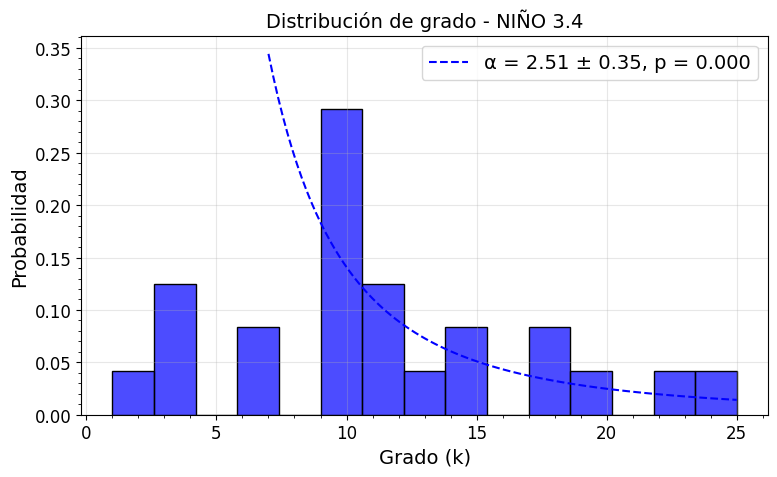

Distribución de grado - NIÑO 3.4
  Estadísticas: media=11.4167, varianza=35.2971, asimetría=0.4679, curtosis=-0.1865
  Exponente de ley de potencia (α): 2.5066 ± 0.3456
  Valor p (vs. exponencial): 0.0000
  → La ley de potencia es significativamente mejor que la exponencial (p < 0.05)
  Grado mínimo: 1, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


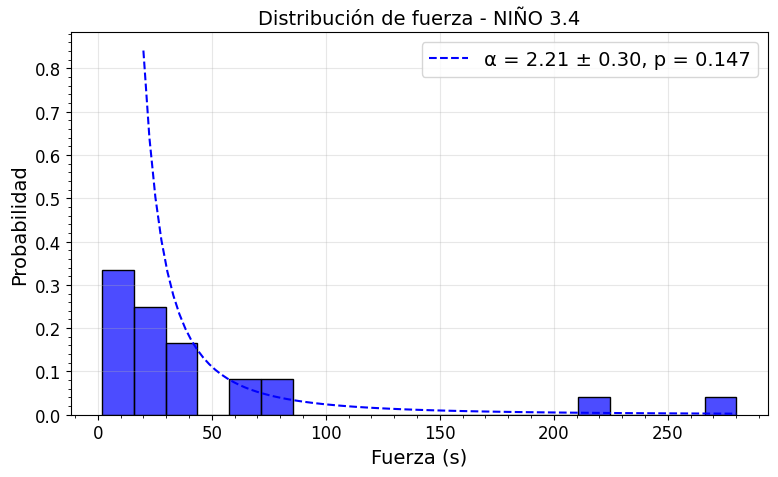

Distribución de fuerza - NIÑO 3.4
  Estadísticas: media=46.5833, varianza=4502.1667, asimetría=2.5611, curtosis=5.7236
  Exponente de ley de potencia (α): 2.2106 ± 0.3027
  Valor p (vs. exponencial): 0.1469
  → No hay evidencia suficiente para preferir la ley de potencia sobre la exponencial
  Fuerza mínima: 2.00, máxima: 280.00



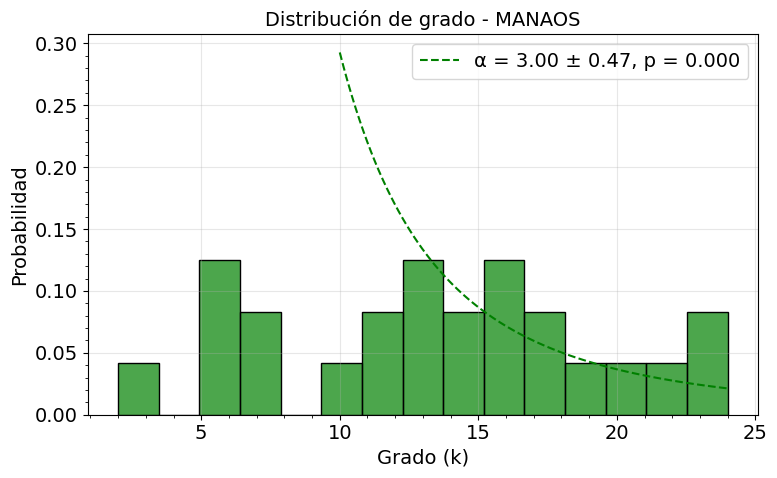

Distribución de grado - MANAOS
  Estadísticas: media=13.5000, varianza=35.6522, asimetría=-0.0707, curtosis=-0.7977
  Exponente de ley de potencia (α): 2.9953 ± 0.4703
  Valor p (vs. exponencial): 0.0000
  → La ley de potencia es significativamente mejor que la exponencial (p < 0.05)
  Grado mínimo: 2, máximo: 24



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


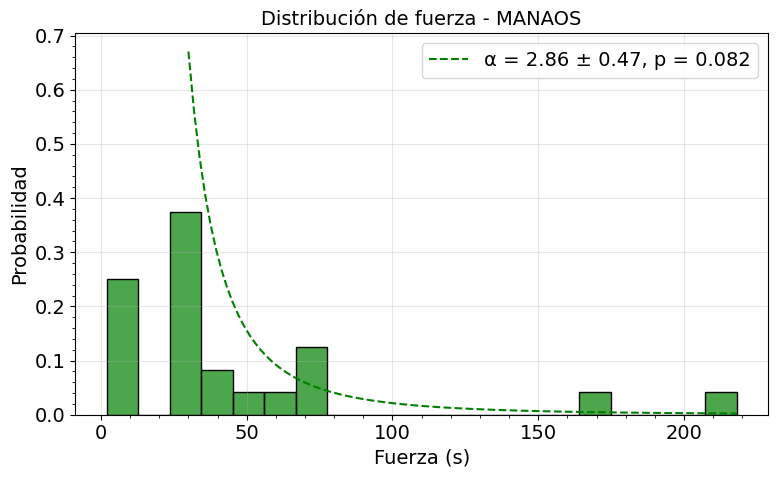

Distribución de fuerza - MANAOS
  Estadísticas: media=46.5833, varianza=2531.7319, asimetría=2.2822, curtosis=4.8130
  Exponente de ley de potencia (α): 2.8626 ± 0.4657
  Valor p (vs. exponencial): 0.0820
  → No hay evidencia suficiente para preferir la ley de potencia sobre la exponencial
  Fuerza mínima: 2.00, máxima: 218.00



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:743: OptimizeWarning: Initial guess is not within the specified bounds
  result = scipy.optimize.minimize(fit_function,


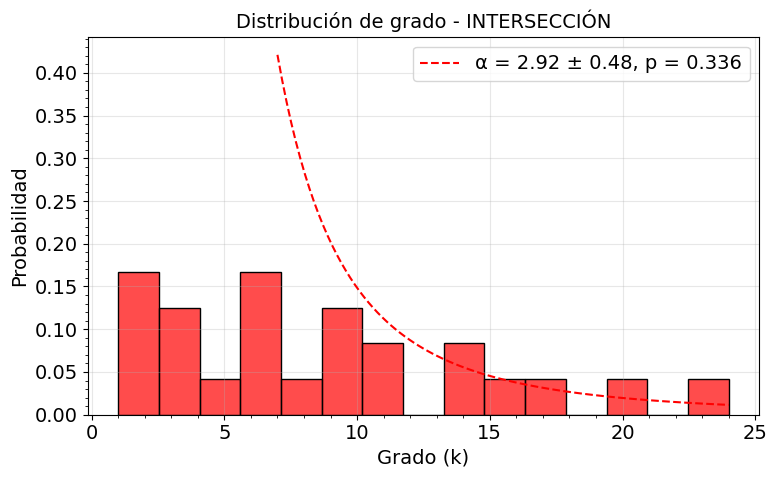

Distribución de grado - INTERSECCIÓN
  Estadísticas: media=8.8333, varianza=36.9275, asimetría=0.7625, curtosis=0.0019
  Exponente de ley de potencia (α): 2.9219 ± 0.4805
  Valor p (vs. exponencial): 0.3357
  → No hay evidencia suficiente para preferir la ley de potencia sobre la exponencial
  Grado mínimo: 1, máximo: 24



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


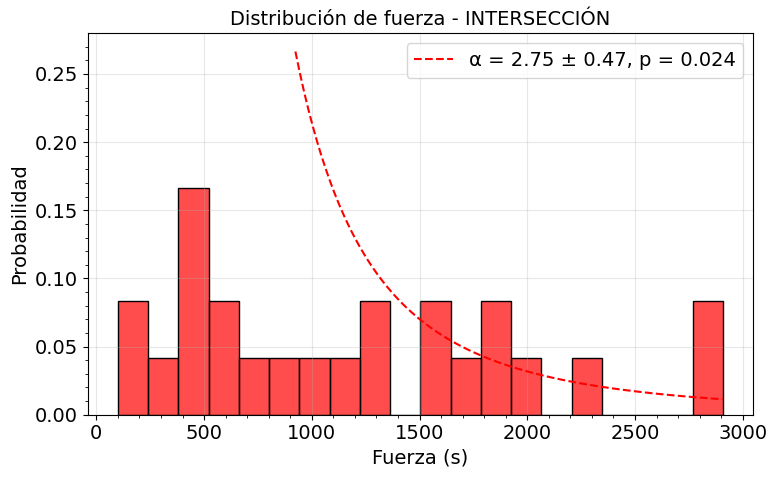

Distribución de fuerza - INTERSECCIÓN
  Estadísticas: media=1175.2905, varianza=669087.7465, asimetría=0.5469, curtosis=-0.7064
  Exponente de ley de potencia (α): 2.7537 ± 0.4687
  Valor p (vs. exponencial): 0.0244
  → La ley de potencia es significativamente mejor que la exponencial (p < 0.05)
  Fuerza mínima: 100.00, máxima: 2907.84



In [32]:
# Suponiendo que tienes G, G1 y GC definidos
plot_degree_distribution(G, "NIÑO 3.4", color='blue', bins=15, loglog=False)
plot_degree_distribution_pesada(G, "NIÑO 3.4", color='blue', bins=20, loglog=False)

plot_degree_distribution(G1, "MANAOS", color='green', bins=15, loglog=False)
plot_degree_distribution_pesada(G1, "MANAOS", color='green', bins=20, loglog=False)

plot_degree_distribution(GC, "INTERSECCIÓN", color='red', bins=15, loglog=False)
plot_degree_distribution_pesada(GC, "INTERSECCIÓN", color='red', bins=20, loglog=False)

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def correlacion_pearson(x, y, nombre_x='Serie X', nombre_y='Serie Y'):
    """
    Calcula la correlación de Pearson entre dos series y genera una gráfica de dispersión.

    Parámetros:
    x, y : listas o arrays unidimensionales de la misma longitud.
    nombre_x, nombre_y : etiquetas para los ejes.

    Retorna:
    r : coeficiente de correlación de Pearson.
    p : valor p asociado.
    """
    x = np.array(x)
    y = np.array(y)
    if len(x) != len(y):
        raise ValueError("Las series deben tener la misma longitud")

    # Calcular correlación de Pearson
    r, p = stats.pearsonr(x, y)

    # Ajuste lineal para la recta de regresión
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Crear gráfica
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Recta de regresión
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f'Regresión lineal (r={r:.3f})')
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    plt.title(f'Correlación de Pearson: r={r:.3f}, p={p:.3e}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    print(f"Coeficiente de correlación de Pearson: r = {r:.4f}")
    print(f"Valor p: {p:.4e}")
    return r, p

##PEARSON

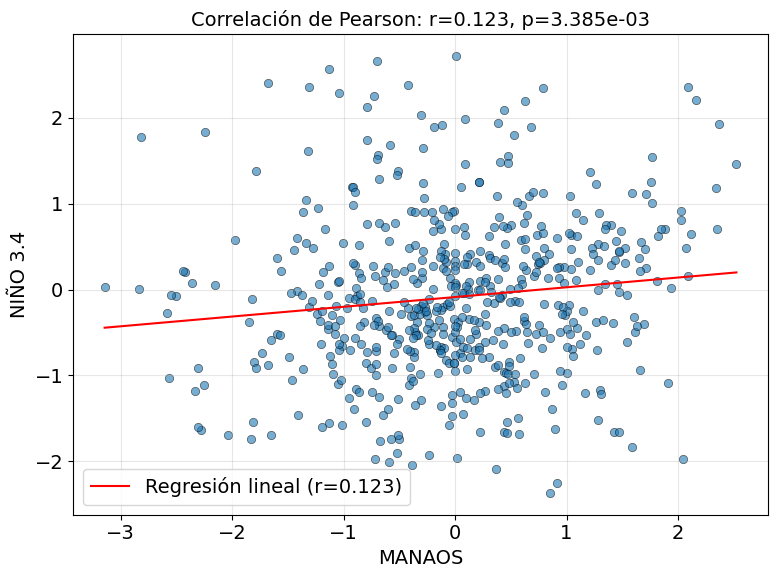

Coeficiente de correlación de Pearson: r = 0.1230
Valor p: 3.3848e-03


In [34]:
# Suponiendo que tienes las series x (NIÑO) y x1 (CALAMAR) definidas
r, p = correlacion_pearson(x1, x, nombre_y='NIÑO 3.4', nombre_x='MANAOS')